<a href="https://colab.research.google.com/github/TanmayJainModi/ML_algorithms/blob/main/Decision_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier ,DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

Implementing Decision tree Classification

In [ ]:
df = pd.read_csv('processed_cleveland.csv',na_values='?')
df = df.dropna()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    int64  
 1   sex       297 non-null    int64  
 2   cp        297 non-null    int64  
 3   trestbps  297 non-null    int64  
 4   chol      297 non-null    int64  
 5   fbs       297 non-null    int64  
 6   restecg   297 non-null    int64  
 7   thalach   297 non-null    int64  
 8   exang     297 non-null    int64  
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    int64  
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  num       297 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 34.8 KB


In [ ]:
#defining features and targets
X = df.drop('num',axis =1)
y = df['num']
y = y.apply(lambda val: 1 if val > 0 else 0)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#split the dataset into training and testing
X_train,X_test,y_train,y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [ ]:
model = DecisionTreeClassifier(criterion='gini',max_depth=5,splitter="best",min_samples_split=5)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=5)

In [ ]:
y_pred_testing = model.predict(X_test)
testing_data_accracy = accuracy_score(y_test, y_pred_testing)
print(testing_data_accracy)

0.8


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
print(f"Precision: {precision_score(y_test, y_pred_testing):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_testing):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_testing):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_testing):.4f}")

Precision: 0.7308
Recall: 0.7917
F1-Score: 0.7600
ROC AUC: 0.7986


[Text(0.5763888888888888, 0.9166666666666666, 'x[11] <= -0.189\ngini = 0.499\nsamples = 237\nvalue = [124.0, 113.0]'),
 Text(0.3333333333333333, 0.75, 'x[12] <= 0.914\ngini = 0.384\nsamples = 139\nvalue = [103.0, 36.0]'),
 Text(0.45486111111111105, 0.8333333333333333, 'True  '),
 Text(0.18055555555555555, 0.5833333333333334, 'x[9] <= 1.413\ngini = 0.243\nsamples = 99\nvalue = [85, 14]'),
 Text(0.1111111111111111, 0.4166666666666667, 'x[0] <= 0.327\ngini = 0.192\nsamples = 93\nvalue = [83, 10]'),
 Text(0.05555555555555555, 0.25, 'x[7] <= -1.052\ngini = 0.062\nsamples = 62\nvalue = [60, 2]'),
 Text(0.027777777777777776, 0.08333333333333333, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.08333333333333333, 0.08333333333333333, 'gini = 0.033\nsamples = 60\nvalue = [59, 1]'),
 Text(0.16666666666666666, 0.25, 'x[4] <= -0.238\ngini = 0.383\nsamples = 31\nvalue = [23, 8]'),
 Text(0.1388888888888889, 0.08333333333333333, 'gini = 0.142\nsamples = 13\nvalue = [12, 1]'),
 Text(0.1944444444444

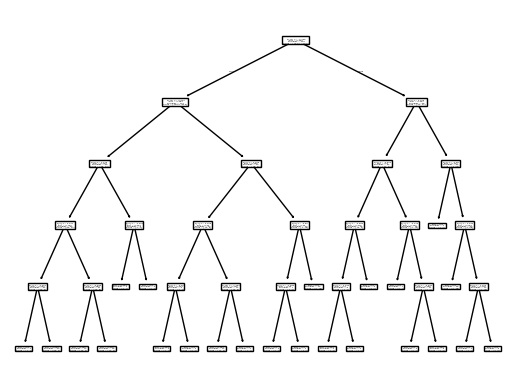

In [ ]:
from sklearn.tree import plot_tree
plot_tree(model)

Implementing Decision Tree Regressor to predict cholestrol

In [ ]:
x = df.drop(['num','chol'],axis = 1)
Y = df['chol']

x_scaled = scaler.fit_transform(x)
Y_scaled = scaler.fit_transform(Y.values.reshape(-1,1))

#splitting the data
x_train , x_test , Y_train ,Y_test = train_test_split(x_scaled,Y_scaled,test_size=0.2,random_state=42)

In [ ]:
dt_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_regressor.fit(x_train, Y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
Y_pred_regressor = dt_regressor.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
print(f"Mean Squared Error: {mean_squared_error(Y_test, Y_pred_regressor)}")
print(f"Mean Absolute Error: {mean_absolute_error(Y_test, Y_pred_regressor)}")
print(f"R2 Score: {r2_score(Y_test, Y_pred_regressor)}")

Mean Squared Error: 1.5166510094046364
Mean Absolute Error: 0.9376598295666686
R2 Score: -0.6270122975014223


In [ ]:
X_train.shape

(237, 13)

[Text(0.4879807692307692, 0.9166666666666666, 'x[1] <= -0.378\nsquared_error = 1.015\nsamples = 237\nvalue = 0.021'),
 Text(0.25961538461538464, 0.75, 'x[11] <= 0.914\nsquared_error = 1.596\nsamples = 71\nvalue = 0.37'),
 Text(0.3737980769230769, 0.8333333333333333, 'True  '),
 Text(0.15384615384615385, 0.5833333333333334, 'x[3] <= -0.377\nsquared_error = 0.967\nsamples = 60\nvalue = 0.155'),
 Text(0.07692307692307693, 0.4166666666666667, 'x[5] <= 0.003\nsquared_error = 0.633\nsamples = 23\nvalue = -0.24'),
 Text(0.038461538461538464, 0.25, 'x[6] <= -0.463\nsquared_error = 0.681\nsamples = 14\nvalue = -0.554'),
 Text(0.019230769230769232, 0.08333333333333333, 'squared_error = 0.145\nsamples = 3\nvalue = -1.4'),
 Text(0.057692307692307696, 0.08333333333333333, 'squared_error = 0.579\nsamples = 11\nvalue = -0.324'),
 Text(0.11538461538461539, 0.25, 'x[8] <= 0.167\nsquared_error = 0.167\nsamples = 9\nvalue = 0.248'),
 Text(0.09615384615384616, 0.08333333333333333, 'squared_error = 0.061\n

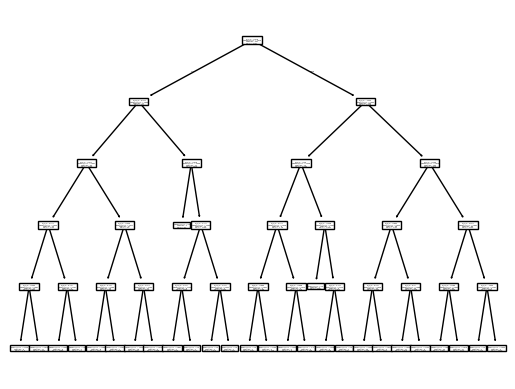

In [ ]:
from sklearn.tree import plot_tree
plot_tree(dt_regressor)